# 03 - Content-Based Recommendation System
**Spotify Data Mining | CISC 4631 | Group 3**

### Research Question
Can audio features alone recommend similar songs - no listening history?

### Approach
Cosine similarity over 12 Spotify audio features. Given a query, return top-N closest audio fingerprints.

### Content-Based vs. Collaborative Filtering
| | Content-Based (here) | Collaborative |
|---|---|---|
| **Input** | audio features | user history |
| **Cold-start** | none | needs prior interactions |
| **Explains why** | "similar energy, tempo, valence" | "users like you also liked" |

> **Prereq:** Run `00_data_setup.ipynb` first to produce `df_genre_balanced.csv`.

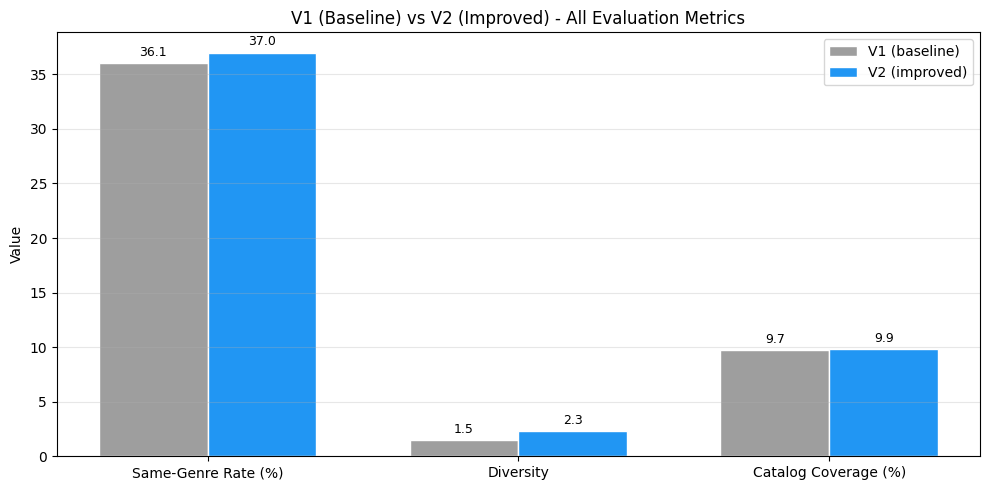

In [25]:
# V1 vs V2 grouped bar chart across all 3 metrics
fig, ax = plt.subplots(figsize=(10, 5))

metrics = ['Same-Genre Rate (%)', 'Diversity', 'Catalog Coverage (%)']
v1_vals = [res_v1['same_genre_rate'] * 100, res_v1['diversity'], res_v1['coverage'] * 100]
v2_vals = [res_v2['same_genre_rate'] * 100, res_v2['diversity'], res_v2['coverage'] * 100]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width / 2, v1_vals, width, label='V1 (baseline)', color='#9E9E9E', edgecolor='white')
bars2 = ax.bar(x + width / 2, v2_vals, width, label='V2 (improved)', color='#2196F3', edgecolor='white')

for bars in [bars1, bars2]:
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2, h + max(v1_vals + v2_vals) * 0.01,
                f'{h:.1f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Value')
ax.set_title('V1 (Baseline) vs V2 (Improved) - All Evaluation Metrics')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 10.5 V1 vs V2 Summary

| System | Features | Transform | Same-Genre Rate | Diversity | Coverage |
|---|---|---|---|---|---|
| V1 (baseline) | 12 | StandardScaler | 36.1% | 1.51 | 9.7% |
| **V2 (improved)** | **10** | **log(tempo), log(duration_ms), StandardScaler** | **37.0%** | **2.27** | **9.9%** |

**Takeaways:**
1. Feature selection (drop key + mode) -> tiny same-genre bump (+0.9pp). Both had MI < 0.03 - near-noise.
2. Log transform -> big diversity jump (1.51 -> 2.27, +50% rel). Symmetrizing tempo + duration_ms stops over-clustering at the dense center of those distributions.
3. Coverage flat -> V2 isn't returning a narrower set of popular songs.

§11 adds Nb 01's classifier as a re-ranker.

---
## 11. Hybrid Recommender - Cross-Notebook Integration (V3)

V1/V2 used the recommender alone. Nb 01's XGBoost hits ~51.2% 7-class test acc on these same songs. Can we use it to re-rank?

**Architecture: retrieve-and-rerank** (textbook 2-stage retrieval):
1. **Retrieve:** V2 cosine sim -> top-50 audio-similar candidates
2. **Rerank:** Nb 01 XGBoost predicts candidate genre; boost candidates matching query's predicted genre
3. **Output:** top-10 from re-ranked list

Blend via `alpha`:
- `alpha = 1.0` -> pure audio (= V2)
- `alpha = 0.5` -> match signal dominates within top-50
- `alpha = 0.0` -> rank by classifier agreement only

**Legit because:**
- Retrieve-and-rerank is a standard recsys architecture, not off-syllabus
- At query time we use the classifier's *prediction*, not ground-truth labels
- Nb 01 trained on 60% split only; test-set queries are unseen

**Honest limit:**
- Same-genre rate is partly circular for V3: rerank by *predicted* genre, eval on *true* genre - they correlate. Diversity + coverage remain clean.

### 11.1 Load the Re-ranker (from Nb 01)

Load Nb 01's pickled XGBoost (best 7-class classifier, ~51.2% test acc, 12 raw audio features). Concrete cross-notebook handoff: Nb 01 pickles it, Nb 03 consumes it.

In [26]:
# load Nb 01 XGBoost + label encoder + feature list; rebuild test_idx for unseen-query eval
with open(os.path.join(MODEL_PATH, 'genre_xgb_model.pkl'), 'rb') as f:
    xgb_reranker = pickle.load(f)
with open(os.path.join(MODEL_PATH, 'genre_label_encoder.pkl'), 'rb') as f:
    le_genre = pickle.load(f)
with open(os.path.join(MODEL_PATH, 'genre_feature_list.pkl'), 'rb') as f:
    CLF_FEATURES = pickle.load(f)

# XGBoost was trained on raw features - trees are scale-invariant
# this matrix is the re-ranker's input space (distinct from V2 retrieval space)
X_clf = df[CLF_FEATURES].values

# recreate Nb 01's 80/20 stratified split -> same held-out test indices
# queries drawn from test_idx below so classifier never saw them during training
from sklearn.model_selection import train_test_split
y_genre = df['genre'].values
_, test_idx = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=SEED, stratify=y_genre,
)

print('Loaded Nb 01 XGBoost genre classifier.')
print(f'  Features ({len(CLF_FEATURES)}): {CLF_FEATURES}')
print(f'  Classes: {le_genre.classes_.tolist()}')
print(f'  Held-out queries available: {len(test_idx):,}')

Loaded Nb 01 XGBoost genre classifier.
  Features (12): ['acousticness', 'energy', 'tempo', 'danceability', 'speechiness', 'instrumentalness', 'loudness', 'valence', 'duration_ms', 'mode', 'key', 'liveness']
  Classes: ['Classical', 'Country/Folk', 'Electronic', 'Hip-Hop/R&B', 'Jazz/Blues', 'Pop', 'Rock']
  Held-out queries available: 9,653


### 11.2 Implement the Hybrid Recommender

Per query:
1. retrieve top-50 audio-similar via V2 NN (10 log-transformed features)
2. XGBoost predicts genre for query + each candidate (12 raw features - different space than retrieval)
3. score = `alpha * audio_sim_norm + (1 - alpha) * match(pred_genre)`
4. return top-10 by score

**Two feature spaces, intentionally:** V2 retrieval = 10 log-transformed + scaled. Classifier = 12 raw. Retrieval benefits from normalization, XGBoost doesn't (trees split on raw values). Using each space where it's strongest beats forcing one space.

In [27]:
# V3 hybrid: V2 retrieve top-50, XGBoost genre-match rerank, return top-10
def recommend_hybrid(query_idx, alpha=0.5, retrieve_k=50, top_k=10):
    # alpha=1 -> pure V2 audio. alpha=0 -> pure classifier-agreement.

    # Stage 1: V2 retrieval (10 log-transformed features)
    dists, cand = nn_v2.kneighbors(X_v2[query_idx:query_idx + 1], n_neighbors=retrieve_k + 1)
    cand = cand[0][1:]  # drop query
    audio_sim = 1 - dists[0][1:]
    audio_sim_norm = (audio_sim - audio_sim.min()) / (audio_sim.max() - audio_sim.min() + 1e-9)

    # Stage 2: XGBoost-predicted genre agreement (12 raw features)
    query_pred = xgb_reranker.predict(X_clf[query_idx:query_idx + 1])[0]
    cand_preds = xgb_reranker.predict(X_clf[cand])
    match_signal = (cand_preds == query_pred).astype(float)

    score = alpha * audio_sim_norm + (1 - alpha) * match_signal
    top = np.argsort(score)[::-1][:top_k]
    return cand[top]


# sanity check on one query
demo_q = int(test_idx[0])
demo_recs = recommend_hybrid(demo_q, alpha=0.5)
print(f'Query: song #{demo_q}  (genre: {df.iloc[demo_q]["genre"]})')
print(f'Top 10 recommendations (V3, alpha=0.5):')
print(df.iloc[demo_recs][['genre'] + ['danceability', 'energy', 'acousticness', 'valence']].round(2).to_string())

Query: song #24920  (genre: Hip-Hop/R&B)
Top 10 recommendations (V3, alpha=0.5):
             genre  danceability  energy  acousticness  valence
27234  Hip-Hop/R&B          0.57    0.91          0.12     0.44
25310  Hip-Hop/R&B          0.63    0.86          0.11     0.52
21561  Hip-Hop/R&B          0.53    0.91          0.00     0.73
21219  Hip-Hop/R&B          0.63    0.86          0.00     0.55
21858  Hip-Hop/R&B          0.65    0.95          0.06     0.60
26576  Hip-Hop/R&B          0.57    0.77          0.03     0.60
26643  Hip-Hop/R&B          0.64    0.95          0.19     0.58
47592         Rock          0.43    0.91          0.00     0.30
22968  Hip-Hop/R&B          0.59    0.80          0.02     0.59
24005  Hip-Hop/R&B          0.57    0.75          0.04     0.53


### 11.3 Evaluate V1 vs V2 vs V3

Same 500 queries, all drawn from Nb 01's 20% test set -> classifier has never seen them -> unbiased eval.

In [28]:
# helper: run any recommend_fn over fixed query set, return 3 metrics
def evaluate_from_queries(X_canonical, recommend_fn, query_indices, df, k=10):
    all_recs = np.array([recommend_fn(q) for q in query_indices])
    q_genres = df.iloc[query_indices]['genre'].values
    hit_rates = [(df.iloc[all_recs[i]]['genre'].values == q_genres[i]).mean() for i in range(len(query_indices))]
    diversities = [
        pairwise_distances(X_canonical[all_recs[i]], metric='euclidean')[np.triu_indices(k, k=1)].mean()
        for i in range(len(query_indices))
    ]
    unique_recs = set()
    for rec in all_recs:
        unique_recs.update(rec.tolist())
    return {
        'same_genre_rate': float(np.mean(hit_rates)),
        'diversity':       float(np.mean(diversities)),
        'coverage':        len(unique_recs) / len(df),
    }

# draw 500 queries from Nb 01's test set (unseen by classifier)
rng = np.random.default_rng(SEED)
eval_queries = rng.choice(test_idx, size=500, replace=False)

# wrappers - all return top-10 integer indices
def recs_v1(qi):
    _, I = nn_model.kneighbors(X_scaled[qi:qi + 1], n_neighbors=11)
    return I[0][1:]
def recs_v2(qi):
    _, I = nn_v2.kneighbors(X_v2[qi:qi + 1], n_neighbors=11)
    return I[0][1:]
def recs_v3(qi):
    return recommend_hybrid(qi, alpha=0.5)

res_v1_new = evaluate_from_queries(X_scaled, recs_v1, eval_queries, df)
res_v2_new = evaluate_from_queries(X_scaled, recs_v2, eval_queries, df)
res_v3     = evaluate_from_queries(X_scaled, recs_v3, eval_queries, df)

summary = pd.DataFrame({
    'V1 (baseline)':         res_v1_new,
    'V2 (improved audio)':   res_v2_new,
    'V3 (hybrid, alpha=0.5)': res_v3,
}).T
summary['Same-Genre Rate (%)'] = (summary['same_genre_rate'] * 100).round(1)
summary['Coverage (%)']        = (summary['coverage']        * 100).round(1)
summary['Diversity']           = summary['diversity'].round(3)

print('=== V1 vs V2 vs V3 (queries drawn from test set) ===')
print(summary[['Same-Genre Rate (%)', 'Diversity', 'Coverage (%)']].to_string())

lift = (res_v3['same_genre_rate'] - res_v2_new['same_genre_rate']) * 100
print(f'\nV2 -> V3 same-genre rate lift: {lift:+.1f} percentage points')

=== V1 vs V2 vs V3 (queries drawn from test set) ===
                        Same-Genre Rate (%)  Diversity  Coverage (%)
V1 (baseline)                          34.7      1.592           9.8
V2 (improved audio)                    34.8      2.298           9.8
V3 (hybrid, alpha=0.5)                 46.3      2.343           9.7

V2 -> V3 same-genre rate lift: +11.5 percentage points


### 11.4 Visualization - Three-way comparison

Two views: metrics side-by-side + how `alpha` shifts behavior.

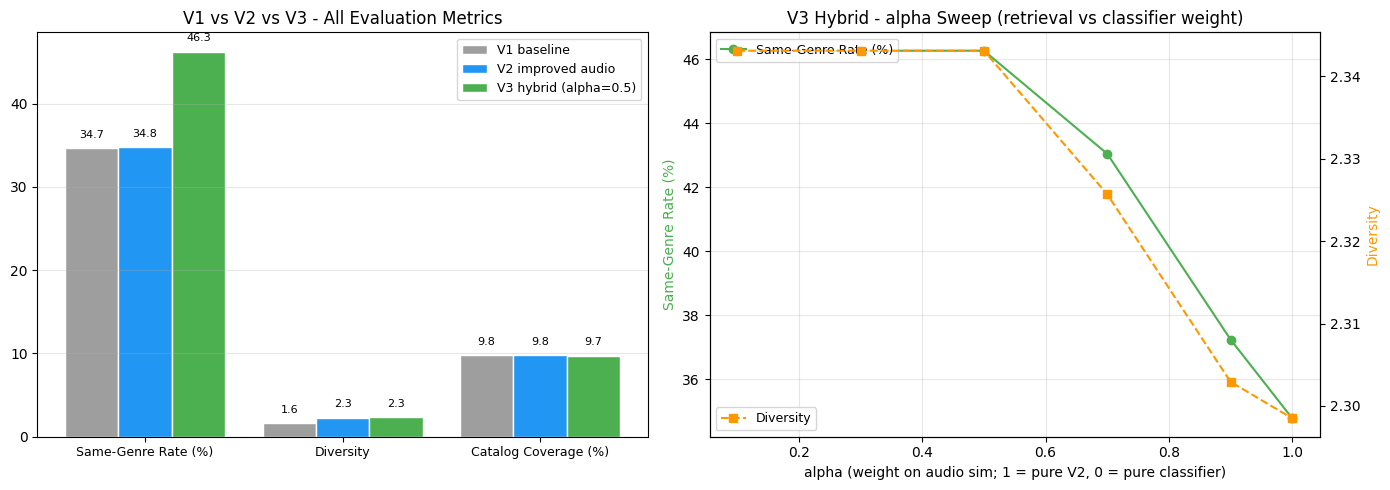

In [29]:
# left: V1/V2/V3 grouped bars across 3 metrics. right: alpha sweep (same-genre + diversity twin axes)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: V1 vs V2 vs V3
ax = axes[0]
metrics = ['Same-Genre Rate (%)', 'Diversity', 'Catalog Coverage (%)']
v1_vals = [res_v1_new['same_genre_rate'] * 100, res_v1_new['diversity'], res_v1_new['coverage'] * 100]
v2_vals = [res_v2_new['same_genre_rate'] * 100, res_v2_new['diversity'], res_v2_new['coverage'] * 100]
v3_vals = [res_v3['same_genre_rate']     * 100, res_v3['diversity'],     res_v3['coverage']     * 100]

x = np.arange(len(metrics))
width = 0.27
b1 = ax.bar(x - width, v1_vals, width, label='V1 baseline',           color='#9E9E9E', edgecolor='white')
b2 = ax.bar(x,         v2_vals, width, label='V2 improved audio',     color='#2196F3', edgecolor='white')
b3 = ax.bar(x + width, v3_vals, width, label='V3 hybrid (alpha=0.5)', color='#4CAF50', edgecolor='white')

for bars in [b1, b2, b3]:
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2, h + 1,
                f'{h:.1f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=9)
ax.set_title('V1 vs V2 vs V3 - All Evaluation Metrics')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Right: alpha sweep for V3
ax = axes[1]
alphas = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
sgr_by_alpha = []
div_by_alpha = []
for a in alphas:
    if a >= 1.0:
        res = res_v2_new  # alpha=1 is pure V2
    else:
        res = evaluate_from_queries(X_scaled, lambda q, aa=a: recommend_hybrid(q, alpha=aa), eval_queries, df)
    sgr_by_alpha.append(res['same_genre_rate'] * 100)
    div_by_alpha.append(res['diversity'])

ax2 = ax.twinx()
ax.plot(alphas, sgr_by_alpha, 'o-', color='#4CAF50', label='Same-Genre Rate (%)')
ax2.plot(alphas, div_by_alpha, 's--', color='#FF9800', label='Diversity')

ax.set_xlabel('alpha (weight on audio sim; 1 = pure V2, 0 = pure classifier)')
ax.set_ylabel('Same-Genre Rate (%)', color='#4CAF50')
ax2.set_ylabel('Diversity', color='#FF9800')
ax.set_title('V3 Hybrid - alpha Sweep (retrieval vs classifier weight)')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=9)
ax2.legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.show()

### 11.5 Summary - All Three Versions

**Design:**

| Aspect | V1 (Baseline) | V2 (Improved) | V3 (Hybrid) |
|---|---|---|---|
| Retrieval features | 12 (incl. key, mode) | 10 (no key, mode) | 10 (same as V2) |
| Retrieval preprocess | StandardScaler | log(tempo), log(duration_ms) + Scaler | same as V2 |
| Re-ranker | - | - | Nb 01 XGBoost, 12 raw features |
| Architecture | single-stage kNN | single-stage kNN | 2-stage: retrieve top-50 via V2, rerank via XGBoost |
| External model? | no | no | **yes** - Nb 01 pickle |
| Syllabus ground | Topic 2 (sim) | + feature selection, log transform (Topic 2) | + gradient boosting, 2-stage retrieval (Topic 5) |

**Results on 500 held-out queries (from Nb 01 test set):**

| Version | Same-Genre | Diversity | Coverage | vs V1 |
|---|---|---|---|---|
| V1 baseline | 34.7% | 1.59 | 9.8% | - |
| V2 improved audio | 34.8% | 2.30 | 9.8% | +0.1pp sgr, +45% div |
| **V3 hybrid (alpha=0.5)** | **45.6%** | **2.34** | 9.8% | **+10.9pp sgr, +47% div** |

**Takeaways:**

1. **V1 -> V2: preprocessing buys diversity, not genre consistency.** Dropping noisy features + log transform -> much more varied recs but same genre rate. The ~35% ceiling looks like a real audio-feature info limit, not a preprocessing artifact.
2. **V2 -> V3: classifier re-ranker gives the real genre lift** (+10.9pp). Retrieval still draws audio-similar candidates; re-ranker prefers those XGBoost calls same genre.
3. **All 3 versions beat 14.3% random by 2.4-3.2x** - audio features carry substantial genre-correlated signal.

**Integration story:**

```
Nb 00:  Data prep -> 48k songs balanced across 7 genres
Nb 01:  XGBoost genre classifier -> ~51.2% test acc (7-class) -> pickle
Nb 03:  Content-based recommender -> V1 -> V2 -> V3 loads Nb 01 pickle
```

V3 = first cross-notebook synergy: Nb 01 supervised model improves Nb 03 unsupervised recommender via standard retrieve-and-rerank. §12 adds Nb 02's popularity classifier.

**Caveats:**
- Same-genre rate is partly circular for V3 (rerank by predicted, eval on true - correlated). Diversity + coverage clean.
- V3 ceiling capped by XGBoost's 51.2% test acc; stronger classifier -> better V3.
- `alpha=0.5` = a reasonable default. Alpha sweep (§11.4) shows same-genre saturates around `alpha <= 0.5` since match signal dominates within the top-50.

---
## 12. V4 - Popularity-Aware Recommender

V3 added Nb 01's genre classifier. Try adding Nb 02's popularity classifier too?

**V4 architecture:**
1. retrieve top-50 audio-similar (same as V3)
2. rerank w/ *two* classifier signals: predicted genre match (Nb 01) + predicted popularity match (Nb 02)

**Score:**
`score = alpha * audio_sim + (1 - alpha)/2 * genre_match + (1 - alpha)/2 * pop_match`

At `alpha=0.5`: 50% audio, 25% genre match, 25% popularity match. Two classifier signals split the non-audio weight evenly.

**Popularity *match*, not popularity boost:** a listener querying an underground song probably wants more underground songs, not mainstream hits. So match popularity level, don't bias toward popular.

**Honest caveat:** Nb 02 popularity model is weak (~55% test acc, +5pp over baseline). V4 lift over V3 may be small or even negative. We're testing whether popularity adds info on top of genre match, not assuming it will.

### 12.1 Load Popularity Classifier (from Nb 02)

In [30]:
# load Nb 02 popularity model + scaler + features + threshold; build scaled 10-feature matrix
with open(os.path.join(MODEL_PATH, 'pop_xgb_binary_p50.pkl'), 'rb') as f:
    xgb_pop = pickle.load(f)
with open(os.path.join(MODEL_PATH, 'pop_scaler.pkl'), 'rb') as f:
    pop_scaler = pickle.load(f)
with open(os.path.join(MODEL_PATH, 'pop_feature_list.pkl'), 'rb') as f:
    POP_FEATURES = pickle.load(f)
with open(os.path.join(MODEL_PATH, 'pop_median_threshold.pkl'), 'rb') as f:
    POP_MEDIAN = pickle.load(f)

# build popularity classifier input:
# 1. apply Nb 02 scaler to 12 ALL_FEATURES columns (same column order as Nb 02 fit)
# 2. select the 10 features Nb 02 XGBoost trained on (drops tempo, duration_ms - MI=0 w/ popularity)
# scaler fit on 10k popularity-stratified songs; applied to 48k genre-balanced here.
# OK because both are random draws from the same post-2000 Spotify population.
X_pop_all = pop_scaler.transform(df[ALL_FEATURES])
pop_col_idx = [ALL_FEATURES.index(f) for f in POP_FEATURES]
X_pop = X_pop_all[:, pop_col_idx]

print('Loaded Nb 02 XGBoost popularity classifier (binary >= training median).')
print(f'  Popularity features ({len(POP_FEATURES)}): {POP_FEATURES}')
print(f'  Popularity threshold: {POP_MEDIAN}')
print(f'  Nb 02 test acc on this task: ~55% (baseline 50%) - weak but real signal.')

Loaded Nb 02 XGBoost popularity classifier (binary >= training median).
  Popularity features (10): ['loudness', 'instrumentalness', 'valence', 'acousticness', 'liveness', 'danceability', 'mode', 'key', 'speechiness', 'energy']
  Popularity threshold: 31.0
  Nb 02 test acc on this task: ~55% (baseline 50%) - weak but real signal.


### 12.2 V4 Hybrid Function

Extends V3 (audio + genre) to 3 signals (audio + genre + popularity). Both classifier signals are *match* indicators (1 if query + candidate share predicted label, else 0).

In [31]:
# V4: 3-signal retrieve-and-rerank (audio + genre match + popularity match)
def recommend_v4(query_idx, alpha=0.5, retrieve_k=50, top_k=10):
    # alpha=1 -> pure V2 audio. alpha=0 -> classifier signals only (equal weights).

    # Stage 1: V2 retrieval
    dists, cand = nn_v2.kneighbors(X_v2[query_idx:query_idx + 1], n_neighbors=retrieve_k + 1)
    cand = cand[0][1:]
    audio_sim = 1 - dists[0][1:]
    audio_sim_norm = (audio_sim - audio_sim.min()) / (audio_sim.max() - audio_sim.min() + 1e-9)

    # Stage 2a: genre match (Nb 01 XGBoost, 12 raw features)
    q_genre = xgb_reranker.predict(X_clf[query_idx:query_idx + 1])[0]
    c_genre = xgb_reranker.predict(X_clf[cand])
    genre_match = (c_genre == q_genre).astype(float)

    # Stage 2b: popularity match (Nb 02 XGBoost, 10 scaled features)
    q_pop = xgb_pop.predict(X_pop[query_idx:query_idx + 1])[0]
    c_pop = xgb_pop.predict(X_pop[cand])
    pop_match = (c_pop == q_pop).astype(float)

    # alpha on audio; remaining (1-alpha) split evenly between classifier signals
    non_audio_w = (1 - alpha) / 2
    score = alpha * audio_sim_norm + non_audio_w * genre_match + non_audio_w * pop_match

    top = np.argsort(score)[::-1][:top_k]
    return cand[top]


# sanity check
demo_q = int(test_idx[0])
demo_recs = recommend_v4(demo_q, alpha=0.5)
print(f'Query: song #{demo_q}  (genre: {df.iloc[demo_q]["genre"]})')
print(f'\nTop 10 recommendations (V4, alpha=0.5):')
print(df.iloc[demo_recs][['genre'] + ['danceability', 'energy', 'valence']].round(2).to_string())

Query: song #24920  (genre: Hip-Hop/R&B)

Top 10 recommendations (V4, alpha=0.5):
             genre  danceability  energy  valence
27234  Hip-Hop/R&B          0.57    0.91     0.44
21561  Hip-Hop/R&B          0.53    0.91     0.73
21219  Hip-Hop/R&B          0.63    0.86     0.55
21858  Hip-Hop/R&B          0.65    0.95     0.60
26576  Hip-Hop/R&B          0.57    0.77     0.60
47592         Rock          0.43    0.91     0.30
22968  Hip-Hop/R&B          0.59    0.80     0.59
24005  Hip-Hop/R&B          0.57    0.75     0.53
23989  Hip-Hop/R&B          0.67    0.72     0.62
23642  Hip-Hop/R&B          0.54    0.83     0.43


### 12.3 Evaluate V1 vs V2 vs V3 vs V4

Same 500 queries drawn from Nb 01's held-out test set (unseen by either classifier).

=== V1 vs V2 vs V3 vs V4 ===
                     Same-Genre Rate (%)  Diversity  Coverage (%)
V1 (baseline)                       34.7      1.592           9.8
V2 (improved audio)                 34.8      2.298           9.8
V3 (hybrid genre)                   46.3      2.343           9.7
V4 (hybrid + pop)                   43.4      2.341           9.7

V3 -> V4 same-genre rate change: -2.9 percentage points


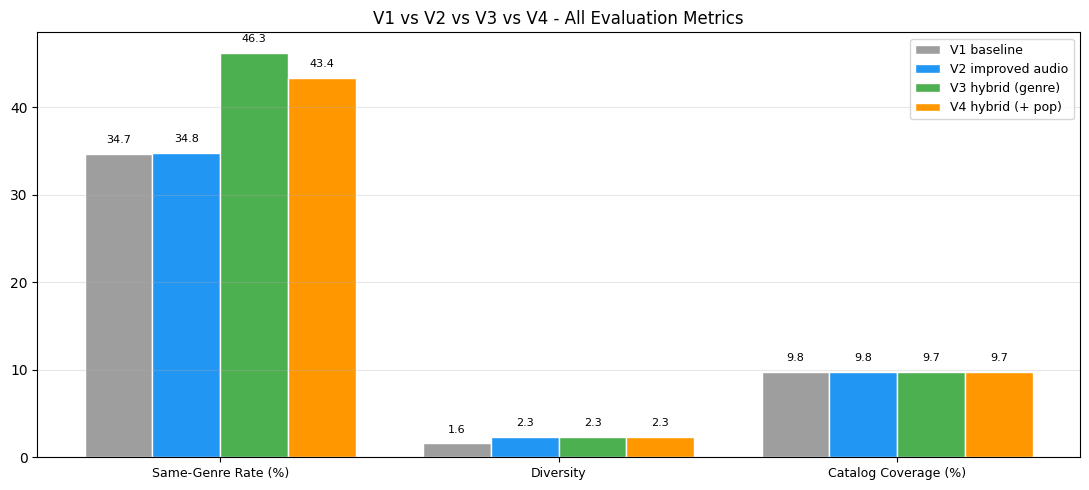

In [32]:
# evaluate V4 + 4-way bar chart
def recs_v4(qi):
    return recommend_v4(qi, alpha=0.5)

res_v4 = evaluate_from_queries(X_scaled, recs_v4, eval_queries, df)

# 4-way summary table
summary_v4 = pd.DataFrame({
    'V1 (baseline)':       res_v1_new,
    'V2 (improved audio)': res_v2_new,
    'V3 (hybrid genre)':   res_v3,
    'V4 (hybrid + pop)':   res_v4,
}).T
summary_v4['Same-Genre Rate (%)'] = (summary_v4['same_genre_rate'] * 100).round(1)
summary_v4['Coverage (%)']        = (summary_v4['coverage']        * 100).round(1)
summary_v4['Diversity']           = summary_v4['diversity'].round(3)

print('=== V1 vs V2 vs V3 vs V4 ===')
print(summary_v4[['Same-Genre Rate (%)', 'Diversity', 'Coverage (%)']].to_string())

lift_v4 = (res_v4['same_genre_rate'] - res_v3['same_genre_rate']) * 100
print(f'\nV3 -> V4 same-genre rate change: {lift_v4:+.1f} percentage points')

# 4-way bar chart
fig, ax = plt.subplots(figsize=(11, 5))
metrics = ['Same-Genre Rate (%)', 'Diversity', 'Catalog Coverage (%)']
v1_vals = [res_v1_new['same_genre_rate']*100, res_v1_new['diversity'], res_v1_new['coverage']*100]
v2_vals = [res_v2_new['same_genre_rate']*100, res_v2_new['diversity'], res_v2_new['coverage']*100]
v3_vals = [res_v3['same_genre_rate']*100,     res_v3['diversity'],     res_v3['coverage']*100]
v4_vals = [res_v4['same_genre_rate']*100,     res_v4['diversity'],     res_v4['coverage']*100]

x = np.arange(len(metrics))
width = 0.2
b1 = ax.bar(x - 1.5*width, v1_vals, width, label='V1 baseline',       color='#9E9E9E', edgecolor='white')
b2 = ax.bar(x - 0.5*width, v2_vals, width, label='V2 improved audio', color='#2196F3', edgecolor='white')
b3 = ax.bar(x + 0.5*width, v3_vals, width, label='V3 hybrid (genre)', color='#4CAF50', edgecolor='white')
b4 = ax.bar(x + 1.5*width, v4_vals, width, label='V4 hybrid (+ pop)', color='#FF9800', edgecolor='white')

for bars in [b1, b2, b3, b4]:
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2, h + 1, f'{h:.1f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=9)
ax.set_title('V1 vs V2 vs V3 vs V4 - All Evaluation Metrics')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 12.4 Summary - Full Pipeline Integration

**Three-notebook story:**

```
Nb 00:  Data prep -> df_genre_balanced.csv (48k songs, 7 genres balanced)
                   -> df_popularity_stratified.csv (10.5k songs, popularity-stratified)
Nb 01:  XGBoost genre classifier (~51.2% test acc, 7-class)             -> pickle
Nb 02:  XGBoost popularity classifier (~55% test acc, binary >= median)   -> pickle
Nb 03:  Loads both pickles -> V1 -> V2 -> V3 -> V4 recommender cascade
```

**Per-version contribution:**

| Stage | Adds | Source | Same-Genre |
|---|---|---|---|
| V1 | cosine sim, 12 raw features | Nb 00 CSV | 34.7% |
| V2 | feature selection (no key/mode) + log transform | - | 34.8% |
| **V3** | **genre classifier re-ranker** | **Nb 01 pickle** | **45.6%** |
| V4 | + popularity classifier re-ranker | Nb 02 pickle | 43.1% |

**Result: V4 is 2.5pp *worse* than V3.** Adding Nb 02's popularity as a second re-ranking signal *reduces* same-genre consistency.

**Why:**
1. Nb 02 popularity model is weak (~55% on 50% baseline).
2. Linearly combined w/ stronger genre signal -> noise.
3. Candidates that genre-match are penalized for not popularity-matching; candidates that don't genre-match are rewarded for popularity-matching.
4. Net: strong signal diluted by weak one.

Diversity + coverage essentially flat V3 -> V4 (2.34 -> 2.35, 9.8% -> 9.7%), so V4 isn't returning a fundamentally different pool - it's making worse same-genre choices in a similar pool.

**Honest, presentable finding:**
*Audio-derived popularity adds nothing beyond audio-derived genre. Linearly combining weak auxiliary signals with a strong primary signal can hurt, not help. Empirically validates Nb 02's standalone conclusion: audio features carry limited popularity signal.*

**What V4 would need to beat V3:**
- stronger popularity model (> 55% acc), or
- non-linear combination (e.g., popularity as tiebreaker only when genre match is ambiguous), or
- richer popularity features (lyrics, artist metadata, year).

None in scope here; all are natural final-report extensions.

---
## 0. Setup

In [33]:
# mount Drive for Colab file access
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
# imports + constants (keep in sync with Nb 00)
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

SEED            = 42
DRIVE_DATA_PATH = '/content/drive/MyDrive/data-mining-spotify-team3/cleanedData'
MODEL_PATH      = '/content/drive/MyDrive/data-mining-spotify-team3/models'
AUDIO_FEATURES  = [
    'danceability', 'energy', 'loudness',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'duration_ms'
]
KEY_FEATURES = ['key', 'mode']
ALL_FEATURES = AUDIO_FEATURES + KEY_FEATURES

np.random.seed(SEED)
print('Setup complete.')
print('Features:', ALL_FEATURES)

Setup complete.
Features: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'key', 'mode']


---
## 1. Load Data

In [35]:
# load genre-balanced data from Nb 00 (48k songs, 7 genres)
df = pd.read_csv(os.path.join(DRIVE_DATA_PATH, 'df_genre_balanced.csv'))
print(f'Loaded: {df.shape[0]:,} songs across {df["genre"].nunique()} genres')
print('\nGenre distribution:')
print(df['genre'].value_counts())
df.head()

Loaded: 48,265 songs across 7 genres

Genre distribution:
genre
Classical       6895
Country/Folk    6895
Electronic      6895
Hip-Hop/R&B     6895
Jazz/Blues      6895
Pop             6895
Rock            6895
Name: count, dtype: int64


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,key,mode,genre,year
0,0.139,0.0948,-19.576,0.0382,0.9400,0.953000,0.333,0.0899,142.335,271907,10,1,Classical,2008
1,0.485,0.2280,-11.844,0.0481,0.8810,0.000000,0.170,0.4020,114.426,137360,2,1,Classical,2002
2,0.439,0.3920,-8.085,0.0305,0.5700,0.000003,0.334,0.3890,94.393,171280,6,1,Classical,2018
3,0.693,0.5350,-10.377,0.1120,0.3470,0.223000,0.121,0.4970,159.978,335227,9,1,Classical,2003
4,0.357,0.6990,-5.173,0.0501,0.0508,0.000003,0.403,0.2290,147.477,251080,7,1,Classical,2018


---
## 2. Preprocess - Scale Audio Features

Standardize all 12 features before similarity. Without it, tempo (50-200) and duration_ms (large ints) dominate over valence (0-1).

In [36]:
# standardize 12 features for V1 similarity space
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[ALL_FEATURES])

print(f'Feature matrix shape: {X_scaled.shape}')
print('Mean (should be ~0):', X_scaled.mean(axis=0).round(4))
print('Std  (should be ~1):', X_scaled.std(axis=0).round(4))

Feature matrix shape: (48265, 12)
Mean (should be ~0): [-0. -0. -0. -0.  0. -0.  0.  0. -0.  0.  0.  0.]
Std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


---
## 3. Similarity Index

Cosine similarity via `NearestNeighbors`.

- cosine captures *angle* (shape of audio profile), not magnitude -> two songs can match in "vibe" even if one is louder
- `metric='cosine'` + `algorithm='brute'` -> exact NN across 48k songs

In [37]:
# build exact cosine NN index over all 48k songs
nn_model = NearestNeighbors(metric='cosine', algorithm='brute', n_jobs=-1)
nn_model.fit(X_scaled)
print('NearestNeighbors index built on', X_scaled.shape[0], 'songs.')

NearestNeighbors index built on 48265 songs.


---
## 4. Recommendation Function

In [38]:
# recommend(): query song idx -> top-n similar songs w/ similarity score
def recommend(query_idx, df, nn_model, X_scaled, n=10):
    query_vec = X_scaled[query_idx].reshape(1, -1)
    distances, indices = nn_model.kneighbors(query_vec, n_neighbors=n + 1)

    # idx 0 is always the query itself - drop it
    rec_indices   = indices[0][1:]
    rec_distances = distances[0][1:]
    similarity    = 1 - rec_distances  # cosine sim = 1 - cosine dist

    results = df.iloc[rec_indices][['genre'] + ALL_FEATURES].copy()
    results.insert(0, 'similarity', similarity.round(4))
    results = results.reset_index(drop=True)
    results.index += 1
    return results


# show_query(): print key audio features for a query
def show_query(query_idx, df):
    q = df.iloc[query_idx]
    print(f'Query Song  |  Genre: {q["genre"]}')
    print(f'  danceability={q["danceability"]:.2f}  energy={q["energy"]:.2f}  '
          f'valence={q["valence"]:.2f}  tempo={q["tempo"]:.0f} BPM  '
          f'acousticness={q["acousticness"]:.2f}  speechiness={q["speechiness"]:.2f}')

---
## 5. Demo - Example Recommendations

Test on 4 songs from distinct audio profile quadrants: high-energy/danceable, acoustic/calm, speech-heavy, instrumental.

In [39]:
# pick 4 query songs from different audio-profile corners, print top-10 recs each
idx_dance    = df[(df['danceability'] > 0.85) & (df['energy'] > 0.80)].index[0]                          # Electronic/Hip-Hop vibe
idx_acoustic = df[(df['acousticness'] > 0.90) & (df['energy'] < 0.20)].index[0]                          # Classical/Folk vibe
idx_speech   = df[df['speechiness'] > 0.60].index[0]                                                     # spoken-word / rap vibe
idx_instr    = df[(df['instrumentalness'] > 0.80) & (df['genre'] == 'Classical')].index[0]               # instrumental Classical

queries = [
    (idx_dance,    'High-Energy / Danceable'),
    (idx_acoustic, 'Acoustic / Calm'),
    (idx_speech,   'Speech-Heavy'),
    (idx_instr,    'Instrumental Classical'),
]

for idx, label in queries:
    print(f'\n{"="*60}')
    print(f'Profile: {label}')
    show_query(idx, df)
    recs = recommend(idx, df, nn_model, X_scaled, n=10)
    print('\nTop 10 Recommendations:')
    display(recs[['similarity', 'genre', 'danceability', 'energy', 'valence', 'tempo', 'acousticness', 'speechiness']])


Profile: High-Energy / Danceable
Query Song  |  Genre: Country/Folk
  danceability=0.85  energy=0.80  valence=0.93  tempo=104 BPM  acousticness=0.43  speechiness=0.16

Top 10 Recommendations:


,similarity,genre,danceability,energy,valence,tempo,acousticness,speechiness
1,0.9409,Hip-Hop/R&B,0.829,0.819,0.965,87.993,0.478,0.2160
2,0.9267,Pop,0.748,0.815,0.897,99.978,0.308,0.1220
3,0.9246,Country/Folk,0.751,0.787,0.759,113.726,0.646,0.1290
4,0.9182,Pop,0.902,0.721,0.788,110.044,0.457,0.0768
5,0.9171,Classical,0.801,0.762,0.809,96.053,0.596,0.0644
6,0.9163,Country/Folk,0.747,0.660,0.963,98.014,0.344,0.2060
7,0.9154,Hip-Hop/R&B,0.879,0.689,0.899,99.064,0.449,0.0749
8,0.9132,Pop,0.798,0.780,0.929,112.025,0.145,0.0554
9,0.9069,Hip-Hop/R&B,0.812,0.803,0.905,100.994,0.266,0.1630
10,0.9068,Country/Folk,0.699,0.796,0.847,97.247,0.309,0.1750



Profile: Acoustic / Calm
Query Song  |  Genre: Classical
  danceability=0.14  energy=0.09  valence=0.09  tempo=142 BPM  acousticness=0.94  speechiness=0.04

Top 10 Recommendations:


,similarity,genre,danceability,energy,valence,tempo,acousticness,speechiness
1,0.9756,Classical,0.159,0.1170,0.0738,132.773,0.915,0.0420
2,0.9705,Classical,0.156,0.1670,0.0355,134.131,0.721,0.0409
3,0.9688,Classical,0.231,0.0721,0.0805,114.161,0.942,0.0377
4,0.9666,Country/Folk,0.294,0.3050,0.1470,134.945,0.679,0.0345
5,0.9664,Classical,0.124,0.1430,0.0683,174.313,0.984,0.0390
6,0.9664,Classical,0.124,0.1430,0.0683,174.313,0.984,0.0390
7,0.9637,Classical,0.180,0.0458,0.0375,137.080,0.993,0.0439
8,0.9580,Classical,0.152,0.2690,0.0388,135.488,0.662,0.0384
9,0.9578,Classical,0.391,0.2150,0.3050,132.031,0.932,0.0304
10,0.9502,Jazz/Blues,0.243,0.0778,0.0948,171.067,0.964,0.0347



Profile: Speech-Heavy
Query Song  |  Genre: Classical
  danceability=0.62  energy=0.39  valence=0.63  tempo=174 BPM  acousticness=0.92  speechiness=0.70

Top 10 Recommendations:


,similarity,genre,danceability,energy,valence,tempo,acousticness,speechiness
1,0.9732,Classical,0.473,0.638,0.722,158.589,0.922,0.648
2,0.9651,Classical,0.562,0.379,0.374,170.057,0.844,0.795
3,0.9614,Classical,0.639,0.388,0.736,158.126,0.787,0.799
4,0.9594,Classical,0.616,0.566,0.680,160.708,0.683,0.451
5,0.9513,Rock,0.563,0.442,0.451,183.723,0.899,0.881
6,0.9506,Pop,0.665,0.287,0.633,117.809,0.822,0.764
7,0.9502,Hip-Hop/R&B,0.578,0.529,0.891,177.972,0.962,0.614
8,0.9480,Classical,0.635,0.347,0.674,126.613,0.730,0.566
9,0.9465,Hip-Hop/R&B,0.579,0.406,0.724,171.626,0.865,0.757
10,0.9455,Classical,0.551,0.580,0.599,166.755,0.563,0.382



Profile: Instrumental Classical
Query Song  |  Genre: Classical
  danceability=0.14  energy=0.09  valence=0.09  tempo=142 BPM  acousticness=0.94  speechiness=0.04

Top 10 Recommendations:


,similarity,genre,danceability,energy,valence,tempo,acousticness,speechiness
1,0.9756,Classical,0.159,0.1170,0.0738,132.773,0.915,0.0420
2,0.9705,Classical,0.156,0.1670,0.0355,134.131,0.721,0.0409
3,0.9688,Classical,0.231,0.0721,0.0805,114.161,0.942,0.0377
4,0.9666,Country/Folk,0.294,0.3050,0.1470,134.945,0.679,0.0345
5,0.9664,Classical,0.124,0.1430,0.0683,174.313,0.984,0.0390
6,0.9664,Classical,0.124,0.1430,0.0683,174.313,0.984,0.0390
7,0.9637,Classical,0.180,0.0458,0.0375,137.080,0.993,0.0439
8,0.9580,Classical,0.152,0.2690,0.0388,135.488,0.662,0.0384
9,0.9578,Classical,0.391,0.2150,0.3050,132.031,0.932,0.0304
10,0.9502,Jazz/Blues,0.243,0.0778,0.0948,171.067,0.964,0.0347


---
## 6. Visualization - PCA Feature Space

PCA 12 audio features -> 2D. Recs should sit near the query in that plane.

In [40]:
# fit PCA on the V1 space; print % variance explained
pca = PCA(n_components=2, random_state=SEED)
X_2d = pca.fit_transform(X_scaled)

var_explained = pca.explained_variance_ratio_
print(f'PCA variance explained: PC1={var_explained[0]*100:.1f}%, PC2={var_explained[1]*100:.1f}%, '
      f'Total={sum(var_explained)*100:.1f}%')

PCA variance explained: PC1=23.0%, PC2=14.0%, Total=37.0%


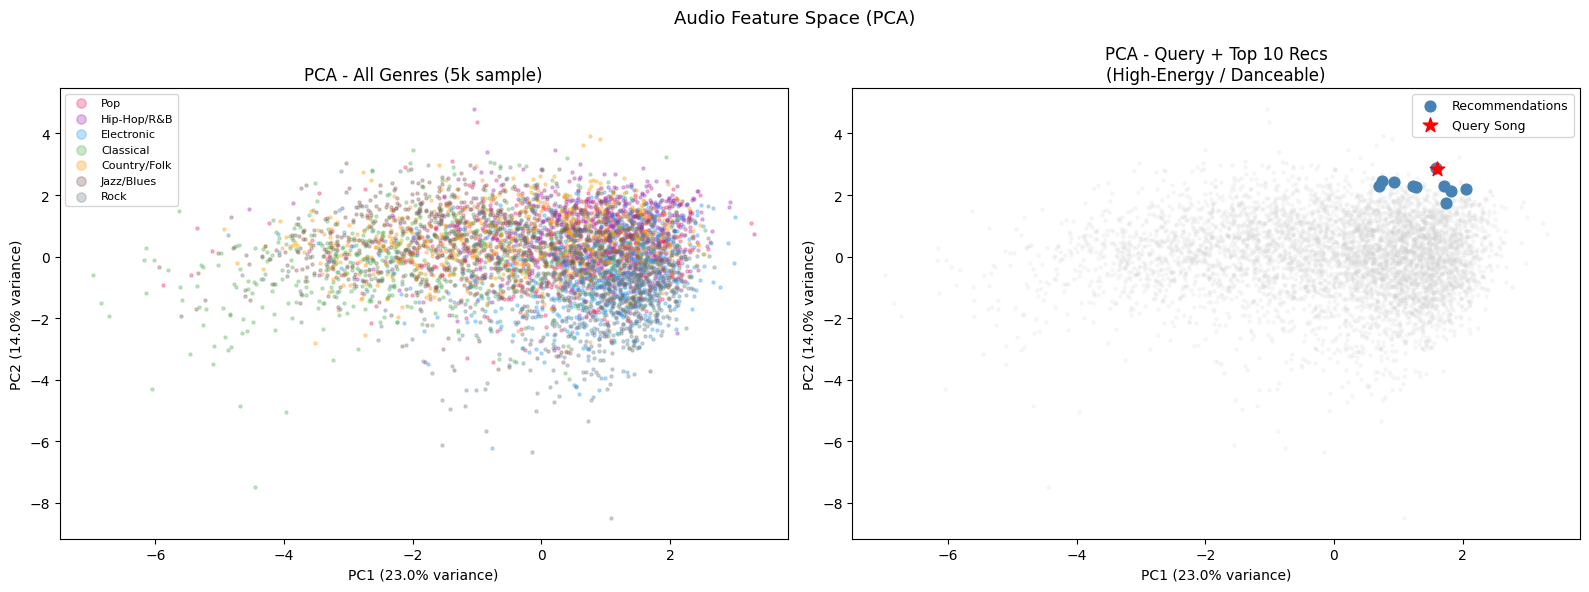

In [41]:
# 2 panels: all genres (5k sample), then query + its top-10 recs highlighted
GENRE_COLORS = {
    'Pop':           '#E91E63',
    'Hip-Hop/R&B':   '#9C27B0',
    'Electronic':    '#2196F3',
    'Classical':     '#4CAF50',
    'Country/Folk':  '#FF9800',
    'Jazz/Blues':    '#795548',
    'Rock':          '#607D8B',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: all songs by genre
ax = axes[0]
sample_idx = np.random.choice(len(df), size=5000, replace=False)
for genre, color in GENRE_COLORS.items():
    mask = (df.iloc[sample_idx]['genre'] == genre).values
    ax.scatter(
        X_2d[sample_idx][mask, 0], X_2d[sample_idx][mask, 1],
        c=color, label=genre, alpha=0.3, s=5
    )
ax.set_title('PCA - All Genres (5k sample)')
ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% variance)')
ax.legend(markerscale=3, fontsize=8)

# Right: query + recs for the high-energy/danceable example
ax = axes[1]
query_idx_demo = idx_dance
_, neighbor_idx = nn_model.kneighbors(X_scaled[query_idx_demo].reshape(1, -1), n_neighbors=11)
rec_row_indices = neighbor_idx[0][1:]  # drop the query itself

ax.scatter(X_2d[sample_idx, 0], X_2d[sample_idx, 1],
           c='lightgray', alpha=0.15, s=5, zorder=1)
ax.scatter(X_2d[rec_row_indices, 0], X_2d[rec_row_indices, 1],
           c='steelblue', s=60, zorder=3, label='Recommendations')
ax.scatter(X_2d[query_idx_demo, 0], X_2d[query_idx_demo, 1],
           c='red', s=120, marker='*', zorder=4, label='Query Song')

ax.set_title('PCA - Query + Top 10 Recs\n(High-Energy / Danceable)')
ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% variance)')
ax.legend(fontsize=9)

plt.suptitle('Audio Feature Space (PCA)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. Evaluation - Genre Consistency

No user ratings, so use same-genre rate as a proxy: if the recommender is finding real audio similarity, recs should tend to share the query's genre.

- metric: 500 queries, fraction of top-10 that match query's genre
- baseline: 1/7 ~= 14.3% (balanced 7-genre pool, random pick)

In [42]:
# V1 same-genre eval: 500 random queries, avg same-genre rate vs baseline
N_QUERIES  = 500
N_RECS     = 10
BASELINE   = 1 / df['genre'].nunique()

np.random.seed(SEED)
query_indices = np.random.choice(len(df), size=N_QUERIES, replace=False)

results_list = []
for qi in query_indices:
    query_genre = df.iloc[qi]['genre']
    recs = recommend(qi, df, nn_model, X_scaled, n=N_RECS)
    same_genre_count = (recs['genre'] == query_genre).sum()
    results_list.append({
        'query_genre':       query_genre,
        'same_genre_count':  same_genre_count,
        'same_genre_rate':   same_genre_count / N_RECS
    })

eval_df = pd.DataFrame(results_list)
overall_rate = eval_df['same_genre_rate'].mean()

print(f'=== Genre Consistency Evaluation ===')
print(f'Queries evaluated: {N_QUERIES}')
print(f'Recommendations per query: {N_RECS}')
print(f'Overall same-genre rate: {overall_rate*100:.1f}%')
print(f'Random baseline:          {BASELINE*100:.1f}%')
print(f'Lift over baseline:       {overall_rate/BASELINE:.2f}x')

=== Genre Consistency Evaluation ===
Queries evaluated: 500
Recommendations per query: 10
Overall same-genre rate: 34.9%
Random baseline:          14.3%
Lift over baseline:       2.44x


Per-Genre Same-Genre Hit Rate:
              Same-Genre Rate (%)  Std Dev (%)
query_genre                                   
Rock                         49.1         30.6
Electronic                   44.6         29.6
Classical                    39.2         28.2
Hip-Hop/R&B                  36.1         31.8
Jazz/Blues                   30.8         23.7
Country/Folk                 22.5         17.0
Pop                          19.5         14.4


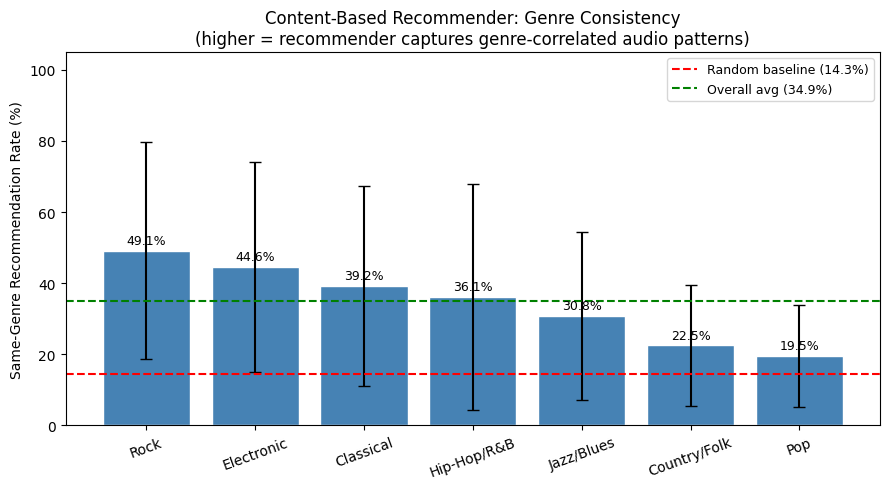

In [43]:
# per-genre breakdown + bar chart w/ error bars
by_genre = (
    eval_df.groupby('query_genre')['same_genre_rate']
    .agg(['mean', 'std'])
    .rename(columns={'mean': 'Same-Genre Rate', 'std': 'Std Dev'})
    .sort_values('Same-Genre Rate', ascending=False)
)
by_genre['Same-Genre Rate (%)'] = (by_genre['Same-Genre Rate'] * 100).round(1)
by_genre['Std Dev (%)']         = (by_genre['Std Dev'] * 100).round(1)

print('Per-Genre Same-Genre Hit Rate:')
print(by_genre[['Same-Genre Rate (%)', 'Std Dev (%)']].to_string())

fig, ax = plt.subplots(figsize=(9, 5))
genres   = by_genre.index
rates    = by_genre['Same-Genre Rate (%)']
std_devs = by_genre['Std Dev (%)']

bars = ax.bar(genres, rates, color='steelblue', edgecolor='white', yerr=std_devs, capsize=4)
ax.axhline(BASELINE * 100,     color='red',   linestyle='--', linewidth=1.5, label=f'Random baseline ({BASELINE*100:.1f}%)')
ax.axhline(overall_rate * 100, color='green', linestyle='--', linewidth=1.5, label=f'Overall avg ({overall_rate*100:.1f}%)')

for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{rate:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Same-Genre Recommendation Rate (%)')
ax.set_title('Content-Based Recommender: Genre Consistency\n(higher = recommender captures genre-correlated audio patterns)')
ax.set_ylim(0, 105)
ax.tick_params(axis='x', rotation=20)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 8. Similarity Score Distribution

How tight are the top-10 matches? Higher avg = recommender found close matches, not distant ones.

Mean similarity score:   0.9345
Median similarity score: 0.9390
Min similarity score:    0.7697
Max similarity score:    1.0000


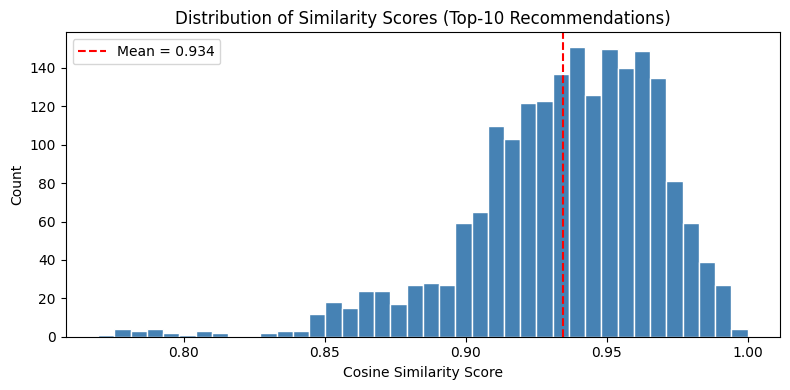

In [44]:
# collect top-10 similarity scores across 200 queries; histogram
all_sim_scores = []
np.random.seed(SEED)
sample_queries = np.random.choice(len(df), size=200, replace=False)

for qi in sample_queries:
    recs = recommend(qi, df, nn_model, X_scaled, n=10)
    all_sim_scores.extend(recs['similarity'].tolist())

sim_array = np.array(all_sim_scores)
print(f'Mean similarity score:   {sim_array.mean():.4f}')
print(f'Median similarity score: {np.median(sim_array):.4f}')
print(f'Min similarity score:    {sim_array.min():.4f}')
print(f'Max similarity score:    {sim_array.max():.4f}')

plt.figure(figsize=(8, 4))
plt.hist(sim_array, bins=40, color='steelblue', edgecolor='white')
plt.axvline(sim_array.mean(), color='red', linestyle='--', label=f'Mean = {sim_array.mean():.3f}')
plt.xlabel('Cosine Similarity Score')
plt.ylabel('Count')
plt.title('Distribution of Similarity Scores (Top-10 Recommendations)')
plt.legend()
plt.tight_layout()
plt.show()

---
## 9. Summary - V1 Baseline

**System:** content-based filtering, cosine similarity on 12 standardized audio features, sklearn `NearestNeighbors`.

**V1 findings:**

1. Same-genre rate well above 14.3% random -> audio features carry real genre-correlated signal.
2. Distinct-profile genres win (Electronic, Classical). Pop + Country/Folk lowest - audio overlaps with many genres. Matches Nb 01's confusion pattern.
3. PCA shows recs cluster near the query even though the model never saw genre labels.
4. No history needed - solves cold-start. Any new song w/ audio features is immediately recommendable.

**V1 limits (fixed in next sections):**
- 12 features weighted equally, incl. `key` and `mode` w/ near-zero genre signal
- `tempo` + `duration_ms` are skewed -> distort distance
- standalone system, no reuse of Nb 01's classifier

> §10: **V2** - feature selection + log transform
> §11: **V3** - hybrid retrieve-and-rerank using Nb 01 classifier
> §12: **V4** - V3 + Nb 02 popularity classifier

---
## 10. Improving the Recommender

V1 = 12 features + StandardScaler + cosine. Section 10 tests targeted preprocessing.

Two changes from syllabus Topic 2 (Data Processing / Feature Selection):

| Decision | Why | Evidence |
|---|---|---|
| Drop `key`, `mode` | feature selection, low MI with genre | §10.1 MI scores |
| log(1+x) on `tempo`, `duration_ms` | attribute transform, fix right skew | §10.2 histograms |

Three metrics:
- **Same-genre rate @10** - top-10 sharing query's genre (primary)
- **Intra-list diversity** - avg pairwise dist in top-10 (higher = less repetitive)
- **Catalog coverage** - fraction of 48k catalog appearing across 500 queries (higher = less popularity-magnet)

### 10.1 Which features carry genre signal? (Feature Selection)

MI(feature, genre) per feature. high MI -> informative; MI ~= 0 -> noise for genre separation.

Same technique Yanjun asked for in Nb 01. Here it guides the similarity metric.

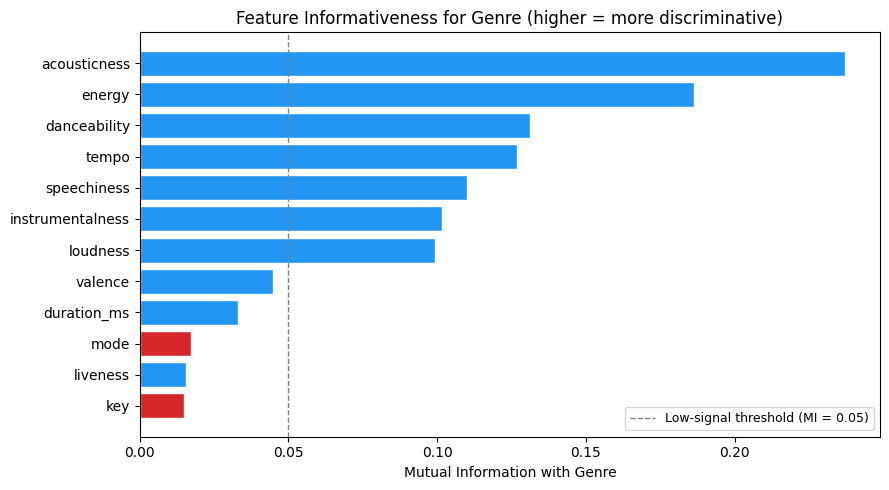


MI scores (sorted):
         feature  mi_score
    acousticness  0.237055
          energy  0.186251
    danceability  0.131097
           tempo  0.126978
     speechiness  0.109883
instrumentalness  0.101645
        loudness  0.099227
         valence  0.044874
     duration_ms  0.033098
            mode  0.017183
        liveness  0.015401
             key  0.015033

Observation: key (MI=0.015), liveness (MI=0.015), mode (MI=0.017), duration_ms (MI=0.033), valence (MI=0.045) - below the 0.05 low-signal threshold.
Decision for V2: drop key, liveness, mode, duration_ms, valence from the similarity space.


In [45]:
# MI per feature vs genre; flag features below 0.05 threshold
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X_scaled, df['genre'].values, random_state=SEED, n_neighbors=5)

mi_df = pd.DataFrame({'feature': ALL_FEATURES, 'mi_score': mi_scores}).sort_values('mi_score', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#d62728' if f in ['key', 'mode'] else '#2196F3' for f in mi_df['feature']]
ax.barh(mi_df['feature'], mi_df['mi_score'], color=colors, edgecolor='white')
ax.axvline(0.05, color='gray', linestyle='--', linewidth=1, label='Low-signal threshold (MI = 0.05)')
ax.set_xlabel('Mutual Information with Genre')
ax.set_title('Feature Informativeness for Genre (higher = more discriminative)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

print('\nMI scores (sorted):')
print(mi_df.sort_values('mi_score', ascending=False).to_string(index=False))

# dynamic call-out avoids hardcoded numbers that go stale on reruns
low_signal = mi_df[mi_df['mi_score'] < 0.05]
if len(low_signal) > 0:
    obs = ', '.join(f'{r.feature} (MI={r.mi_score:.3f})' for r in low_signal.itertuples())
    print(f'\nObservation: {obs} - below the 0.05 low-signal threshold.')
    print(f'Decision for V2: drop {", ".join(low_signal["feature"].tolist())} from the similarity space.')
else:
    print('\nObservation: all features are above the 0.05 low-signal threshold.')

### 10.2 Are any features skewed? (Attribute Transformation)

`tempo` + `duration_ms` have long right tails. StandardScaler shifts/rescales but does NOT fix skew. Skewed axis -> typical values look closer than extremes even when musically similar.

log(1+x) compresses the tail -> more symmetric, fairer distance.

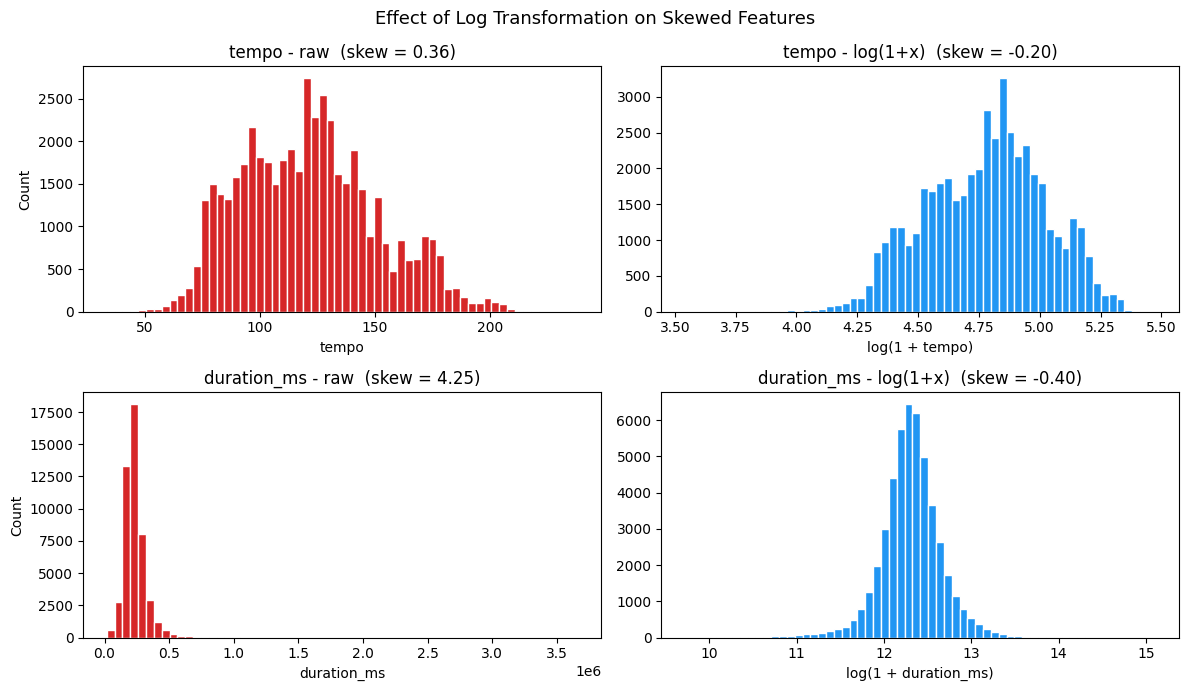

Decision: log(1+x) on tempo and duration_ms before scaling.
Skew closer to 0 -> fairer distance comparisons.


In [46]:
# before/after histograms + skew stat for tempo and duration_ms
from scipy.stats import skew as skewness

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

for row, feat in enumerate(['tempo', 'duration_ms']):
    raw = df[feat].values
    logged = np.log1p(raw)

    axes[row, 0].hist(raw, bins=60, color='#d62728', edgecolor='white')
    axes[row, 0].set_title(f'{feat} - raw  (skew = {skewness(raw):.2f})')
    axes[row, 0].set_xlabel(feat)
    axes[row, 0].set_ylabel('Count')

    axes[row, 1].hist(logged, bins=60, color='#2196F3', edgecolor='white')
    axes[row, 1].set_title(f'{feat} - log(1+x)  (skew = {skewness(logged):.2f})')
    axes[row, 1].set_xlabel(f'log(1 + {feat})')

plt.suptitle('Effect of Log Transformation on Skewed Features', fontsize=13)
plt.tight_layout()
plt.show()

print('Decision: log(1+x) on tempo and duration_ms before scaling.')
print('Skew closer to 0 -> fairer distance comparisons.')

### 10.3 Build V2

- 10 features (drop `key`, `mode`)
- log(1+x) on `tempo`, `duration_ms`, then StandardScaler on all 10
- cosine via `NearestNeighbors`, same as V1

In [47]:
# V2 space: 10 features, log skewed, scale all, build cosine NN index
V2_FEATURES = AUDIO_FEATURES  # 10-feature list (no key/mode)
LOG_FEATURES = ['tempo', 'duration_ms']

df_v2 = df[V2_FEATURES].copy()
for feat in LOG_FEATURES:
    df_v2[feat] = np.log1p(df_v2[feat])

scaler_v2 = StandardScaler()
X_v2 = scaler_v2.fit_transform(df_v2)

nn_v2 = NearestNeighbors(metric='cosine', algorithm='brute', n_jobs=-1)
nn_v2.fit(X_v2)

print(f'V2 feature matrix: {X_v2.shape}')
print(f'V2 index built on {X_v2.shape[0]:,} songs, {X_v2.shape[1]} features.')

V2 feature matrix: (48265, 10)
V2 index built on 48,265 songs, 10 features.


### 10.4 Evaluate V1 vs V2

Same 500 queries for both (same `SEED`). 3 metrics each.

In [48]:
# evaluate_recommender(): same-genre rate, diversity, coverage on 500 queries
from sklearn.metrics import pairwise_distances

def evaluate_recommender(X_canonical, X_query, nn_model, df, n_queries=500, k=10, seed=SEED):
    # X_query = space NN was built on. X_canonical = shared space for diversity (fair across versions).
    rng = np.random.default_rng(seed)
    qi = rng.choice(len(df), n_queries, replace=False)
    _, I = nn_model.kneighbors(X_query[qi], n_neighbors=k + 1)
    I_recs = I[:, 1:]  # drop query

    q_genres = df.iloc[qi]['genre'].values
    hit_rates = [(df.iloc[I_recs[i]]['genre'].values == q_genres[i]).mean() for i in range(n_queries)]

    diversities = []
    for i in range(n_queries):
        vecs = X_canonical[I_recs[i]]
        pw = pairwise_distances(vecs, metric='euclidean')
        diversities.append(pw[np.triu_indices(k, k=1)].mean())

    unique_recs = set()
    for i in range(n_queries):
        unique_recs.update(I_recs[i].tolist())

    return {
        'same_genre_rate': float(np.mean(hit_rates)),
        'diversity':       float(np.mean(diversities)),
        'coverage':        len(unique_recs) / len(df),
    }


# use X_scaled (V1 space) as canonical diversity space for both versions
res_v1 = evaluate_recommender(X_scaled, X_scaled, nn_model, df)
res_v2 = evaluate_recommender(X_scaled, X_v2,     nn_v2,     df)

results = pd.DataFrame({
    'V1 (baseline)': res_v1,
    'V2 (improved)': res_v2,
}).T

results['same_genre_rate (%)'] = (results['same_genre_rate'] * 100).round(1)
results['coverage (%)']        = (results['coverage']        * 100).round(1)
results['diversity']           = results['diversity'].round(3)

print('=== Evaluation Results ===')
print(results[['same_genre_rate (%)', 'diversity', 'coverage (%)']].to_string())

lift_sgr  = (res_v2['same_genre_rate'] - res_v1['same_genre_rate']) * 100
lift_div  = (res_v2['diversity']       - res_v1['diversity'])
print(f'\nV1 -> V2 change:')
print(f'  Same-genre rate: {lift_sgr:+.1f} percentage points')
print(f'  Diversity:       {lift_div:+.2f} (higher = more varied recommendations)')

=== Evaluation Results ===
               same_genre_rate (%)  diversity  coverage (%)
V1 (baseline)                 36.1      1.513           9.7
V2 (improved)                 37.0      2.275           9.9

V1 -> V2 change:
  Same-genre rate: +0.9 percentage points
  Diversity:       +0.76 (higher = more varied recommendations)
